In [1]:
## Imports

import iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import iris.plot as iplt
import iris.quickplot as qplt
import iris.analysis.cartography
import iris.analysis
import aeolus
import aeolus.coord
import aeolus.calc
import stratify
import warnings

In [2]:
## Downloading the data from "The TRAPPIST-1 Habitable Atmosphere Intercomparison (THAI). II. Moist Cases - The Two Waterworlds" by Sergeev et al. (2022)
## [THAI Hab1 case] Surface: ocean only. Atmosphere: 1 bar of N2

Hab1_UM_THAI = iris.load('/data/cluster4/jj22956/thunderstruck_files/Hab1_UM_1_10.nc')
# Hab1_UM_THAI

/home/jj22956/.local/lib/python3.12/site-packages/iris/loading.py:717: IrisLoadWarning: Not all file objects were parsed correctly. See iris.loading.LOAD_PROBLEMS for details.
  warnings.warn(message, category=IrisLoadWarning)


In [3]:
## [THAI Hab2 case] Surface: ocean only. Atmosphere: 1 bar of CO2
Hab2_UM_THAI = iris.load('/data/cluster4/jj22956/thunderstruck_files/Hab2_UM_1_10.nc')

In [4]:
## Extracting the air temperature and air pressure cubes that have the same length via their STASH codes

H1air_temperature = Hab1_UM_THAI.extract_cube('m01s16i004')
# H1air_temperature
H1air_pressure = Hab1_UM_THAI.extract_cube('m01s00i408')
# print(H1air_pressure)

H2air_temperature = Hab2_UM_THAI.extract_cube('m01s16i004')
# H2air_temperature
H2air_pressure = Hab2_UM_THAI.extract_cube('m01s00i408')
# print(H2air_pressure)

In [5]:
Hab2_UM_THAI

Bulk Cloud Fraction In Each Layer (1),time,--,latitude,longitude
Shape,244,39,90,144
Dimension coordinates,,,,
time,x,-,-,-
latitude,-,-,x,-
longitude,-,-,-,x
Auxiliary coordinates,,,,
Fraction of orographic height,-,x,-,-
atmosphere_hybrid_height_coordinate,-,x,-,-
height_above_reference_ellipsoid,-,x,-,-
model_level_number,-,x,-,-


In [6]:
## Reduce cubes to their temporal means (so from 4D to 3D)

H1airtemp_t_mean = aeolus.calc.stats.time_mean(H1air_temperature)
H1airpressure_t_mean = aeolus.calc.stats.time_mean(H1air_pressure)
# print(H1airtemp_t_mean)
# print(H1airpressure_t_mean)

H2airtemp_t_mean = aeolus.calc.stats.time_mean(H2air_temperature)
H2airpressure_t_mean = aeolus.calc.stats.time_mean(H2air_pressure)
# print(H2airtemp_t_mean)
# print(H2airpressure_t_mean)

/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'time', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'time'. Ignoring bounds.
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'time', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'time'. Ignoring bounds.
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'time', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'time'. Ignoring bounds.


/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'time', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'time'. Ignoring bounds.
  warnings.warn(


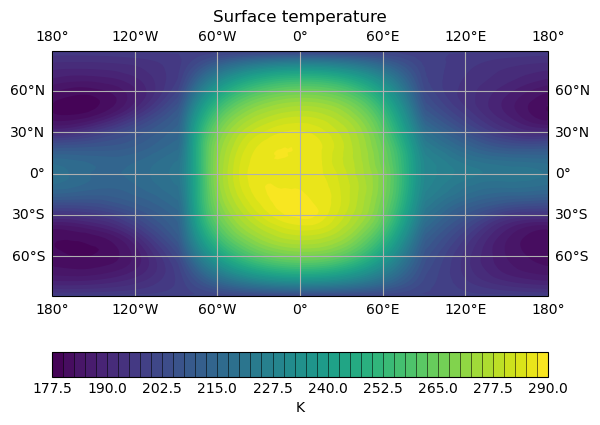

In [7]:
## Contour plot of air temperature, shows clear dayside/nightside contrast
H1surf_temperature = Hab1_UM_THAI.extract_cube('m01s00i024')
H1surf_temp_t_mean = aeolus.calc.stats.time_mean(H1surf_temperature)

qplt.contourf(H1surf_temp_t_mean, 50)
plt.gca().gridlines(draw_labels=True)
plt.show()


In [8]:
# Reduce the zone of the cubes further to just the substellar point (can't wrap cube to average over dayside unfortunately)

H1substellar_temp = H1airtemp_t_mean.extract(iris.Constraint(longitude = 0, latitude = 0))
H1substellar_pressure = H1airpressure_t_mean.extract(iris.Constraint(longitude = 0, latitude = 0))

H2substellar_temp = H2airtemp_t_mean.extract(iris.Constraint(longitude = 0, latitude = 0))
H2substellar_pressure = H2airpressure_t_mean.extract(iris.Constraint(longitude = 0, latitude = 0))

In [9]:
## Calculate sigma pressure (sigma = air_pressure / surface_pressure), converting to Pa

H1surface_pressure_bar = 1
H1sigma_pressure = H1substellar_pressure/(H1surface_pressure_bar*100000)

H2surface_pressure_bar = 1
H2sigma_pressure = H2substellar_pressure/(H2surface_pressure_bar*100000)

In [10]:
## Air temperature as a function of height (model level number), optional plot

# iplt.plot(substellar_temp)
# plt.ylabel('Temperature / K')
# plt.xlabel('Level Number')
# plt.grid()
# plt.show()

In [11]:
## Air pressure as a function of height (model level number), optional plot

# iplt.plot(H1sigma_pressure)
# plt.ylabel(r'$\sigma$')
# plt.gca().invert_yaxis()
# plt.xlabel('Level Number')
# plt.grid()
# plt.show()

In [12]:
## ISA (International Standard Atmosphere) with troposphere

ISA_p_wtrop = np.arange(0, 100000, 10)
ISA_t_wtrop = np.zeros(len(ISA_p_wtrop))

def temp_strat(pressure: float) -> float:
    """International Standard Atmosphere stratospheric temperature."""
    if pressure > 22632:
        return 288.15 - 71.5 * np.log(pressure / 101325) / np.log(22632 / 101325)
    elif pressure > 5474.9:
        return 216.6
    elif pressure > 868.02:
        return 216.6 + 12.0 * np.log(pressure / 5474.9) / np.log(868.02 / 5474.9)
    elif pressure > 110.91:
        return 228.6 + 42.0 * np.log(pressure / 868.02) / np.log(110.91 / 868.02)
    elif pressure > 66.939:
        return 270.6
    else:
        return 270.6 - 56.0 * np.log(pressure / 66.939) / np.log(3.9564 / 66.939)


for i in range(len(ISA_p_wtrop)):
    pressure = ISA_p_wtrop[i]
    ISA_t_wtrop[i] = temp_strat(pressure)

ISA_surface_pressure_bar = 1
ISAlog10_sigma_pressures_wtrop = np.log10(ISA_p_wtrop/(ISA_surface_pressure_bar*100000))


/tmp/ipykernel_2835559/1663941759.py:19: RuntimeWarning: divide by zero encountered in log
  return 270.6 - 56.0 * np.log(pressure / 66.939) / np.log(3.9564 / 66.939)
/tmp/ipykernel_2835559/1663941759.py:27: RuntimeWarning: divide by zero encountered in log10
  ISAlog10_sigma_pressures_wtrop = np.log10(ISA_p_wtrop/(ISA_surface_pressure_bar*100000))


In [13]:
## saving the ISA as used in Aglyamov et al. (2021) with troposphere added

np.savetxt('/data/cluster4/jj22956/pr92_thunderstruck_files/ISA_sigmas_with_troposphere.txt', ISAlog10_sigma_pressures_wtrop)
np.savetxt('/data/cluster4/jj22956/pr92_thunderstruck_files/ISA_temps_with_troposphere.txt', ISA_t_wtrop)

In [14]:
## ISA (International Standard Atmosphere) without troposphere

ISA_p_notrop = np.arange(0, 5474, 10)
ISA_t_notrop = np.zeros(len(ISA_p_notrop))

def temp_strat(pressure: float) -> float:
    """International Standard Atmosphere stratospheric temperature."""
    if pressure > 5474.9:
        return 216.6
    elif pressure > 868.02:
        return 216.6 + 12.0 * np.log(pressure / 5474.9) / np.log(868.02 / 5474.9)
    elif pressure > 110.91:
        return 228.6 + 42.0 * np.log(pressure / 868.02) / np.log(110.91 / 868.02)
    elif pressure > 66.939:
        return 270.6
    else:
        return 270.6 - 56.0 * np.log(pressure / 66.939) / np.log(3.9564 / 66.939)


for i in range(len(ISA_p_notrop)):
    pressure = ISA_p_notrop[i]
    ISA_t_notrop[i] = temp_strat(pressure)

ISA_surface_pressure_bar = 1
ISAlog10_sigma_pressures_notrop = np.log10(ISA_p_notrop/(ISA_surface_pressure_bar*100000))


/tmp/ipykernel_2835559/701765027.py:17: RuntimeWarning: divide by zero encountered in log
  return 270.6 - 56.0 * np.log(pressure / 66.939) / np.log(3.9564 / 66.939)
/tmp/ipykernel_2835559/701765027.py:25: RuntimeWarning: divide by zero encountered in log10
  ISAlog10_sigma_pressures_notrop = np.log10(ISA_p_notrop/(ISA_surface_pressure_bar*100000))


In [15]:
## Saving the ISA as used in Aglyamov et al. (2021) - no troposphere

np.savetxt('/data/cluster4/jj22956/pr92_thunderstruck_files/ISA_sigmas_no_troposphere.txt', ISAlog10_sigma_pressures_notrop)
np.savetxt('/data/cluster4/jj22956/pr92_thunderstruck_files/ISA_temps_no_troposphere.txt', ISA_t_notrop)

In [16]:
## Retrieving and flattening (only needed if taking zonal average, not technically necessary in this case) the data points for air temperature and air pressure
## Using log_10(sigma_pressure) instead as looking at hydrostatic equation, height is proportional to log of pressure with constants R, g and average T in a layer of atmosphere

H1AIRTEMP_FLAT = (H1substellar_temp.data).flatten()
H1SIG_AIRPRESSURE_FLAT = (H1sigma_pressure.data).flatten()
H1temps = H1AIRTEMP_FLAT
# H1sig_pressures = H1SIG_AIRPRESSURE_FLAT
H1log10_sig_pressures = np.log10(H1SIG_AIRPRESSURE_FLAT)

print(len(H1temps), len(H1log10_sig_pressures))
# print(H1log10_sig_pressures)


H2AIRTEMP_FLAT = (H2substellar_temp.data).flatten()
H2SIG_AIRPRESSURE_FLAT = (H2sigma_pressure.data).flatten()
H2temps = H2AIRTEMP_FLAT
# H2sig_pressures = H2SIG_AIRPRESSURE_FLAT
H2log10_sig_pressures = np.log10(H2SIG_AIRPRESSURE_FLAT)

print(len(H2temps), len(H2log10_sig_pressures))
# print(H2log10_sig_pressures)

42 42
39 39


In [17]:
## Surface temperature at the substellar point
print(H1temps[0])

285.2856


In [18]:
# plt.plot(ISA_t, ISAlog10_sigma_pressures, color= 'b')
# plt.scatter(ISA_t, ISAlog10_sigma_pressures, s = 10, facecolor = 'black', zorder = 3)
# plt.gca().invert_yaxis()
# plt.xlabel('Temperature / K')
# plt.ylabel(r'log$_{10}\sigma$')
# plt.title('ISA')
# plt.legend()
# plt.grid()
# plt.show()

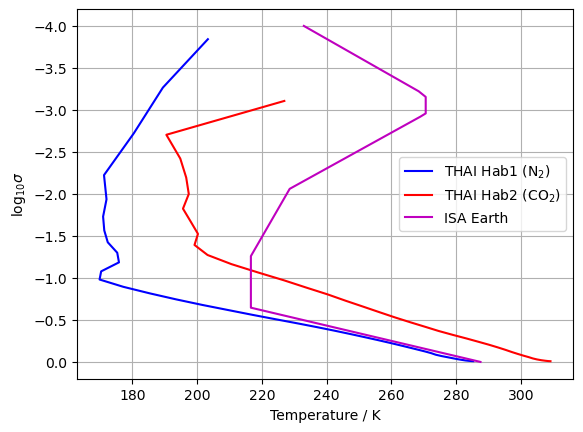

In [20]:
## Plot the temperature profile wrt log_10(sigma), note that the y-axis naturally follows a log scale
plt.rcParams.update({'font.size': 10})


plt.plot(H1temps, H1log10_sig_pressures, color= 'b', label = r'THAI Hab1 (N$_2$)')
# plt.scatter(H1temps, H1log10_sig_pressures, s = 10, facecolor = 'black', zorder = 3)

plt.plot(H2temps, H2log10_sig_pressures, color= 'r', label = r'THAI Hab2 (CO$_2$)')
# plt.scatter(H2temps, H2log10_sig_pressures, s = 10, facecolor = 'black', zorder = 3)

plt.plot(ISA_t_wtrop, ISAlog10_sigma_pressures_wtrop, color= 'm', label = 'ISA Earth')
# plt.scatter(ISA_t, ISAlog10_sigma_pressures, s = 5, facecolor = 'black', zorder = 3)

plt.gca().invert_yaxis()
plt.xlabel('Temperature / K')
plt.ylabel(r'log$_{10}\sigma$')
# plt.title('Air temperature profile for 1 bar surface pressure')
# plt.legend(bbox_to_anchor =(0.5, 0.55))
plt.legend()
plt.grid()
plt.savefig('/data/cluster4/jj22956/lightning_figures/UM_THAI_N2_CO2_ISA.pdf')
plt.show()

In [21]:
## This is for finding where the troposphere/stratosphere/mesosphere layers start and end in the code (via indexing)
print('Stratosphere: ', np.array(np.where(H1log10_sig_pressures<-1))) 
print('Mesosphere: ', np.array(np.where(H1log10_sig_pressures<-2))) 
print('Troposphere: ', np.array(np.where(H1log10_sig_pressures > -1)))
print(H1log10_sig_pressures[0], H1log10_sig_pressures[29], H1log10_sig_pressures[30], H1log10_sig_pressures[37])

Stratosphere:  [[30 31 32 33 34 35 36 37 38 39 40 41]]
Mesosphere:  [[37 38 39 40 41]]
Troposphere:  [[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
  24 25 26 27 28 29]]
-0.009098277527851846 -0.9810631739516515 -1.0781909292093081 -2.2240176768140487


In [22]:
## Constraining the stratosphere data points (and mesosphere, needed to make the polynomial fit better)

strat_log10_sigma_p = H1log10_sig_pressures[np.where(H1log10_sig_pressures<-0.9)]
strat_temps = H1temps[np.where(H1log10_sig_pressures<-0.9)]
# print(len(strat_sig_pressures), len(strat_temps))
# print(strat_sig_pressures, strat_temps)

## Doing the same for the mesosphere

meso_log10_sigma_p = H1log10_sig_pressures[np.where(H1log10_sig_pressures<-2)]
meso_temps = H1temps[np.where(H1log10_sig_pressures<-2)]

## And finally for the troposphere
trop_log10_sigma_p = H1log10_sig_pressures[np.where(H1log10_sig_pressures>-1)]
trop_temps = H1temps[np.where(H1log10_sig_pressures>-1)]


In [23]:
## This is for the stratosphere

strat_z = np.polyfit(strat_log10_sigma_p, strat_temps, 5)
stratfunction = np.poly1d(strat_z)

poly_strat_sigmas = np.linspace(-2.25, -0.9, 50)
poly_strat_temps = stratfunction(poly_strat_sigmas)

stratfunction

poly1d([  9.20068181, 101.56421447, 421.68814786, 824.21892193,
       758.56453597, 435.70600617])

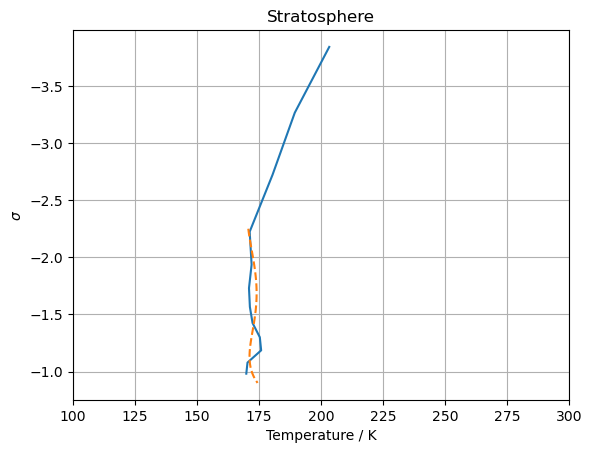

In [24]:
plt.plot(strat_temps, strat_log10_sigma_p, '-', poly_strat_temps, poly_strat_sigmas, '--')
plt.gca().invert_yaxis() # Pressure decreases with height
plt.xlabel('Temperature / K')
plt.ylabel(r'$\sigma$')
plt.title('Stratosphere')
plt.xlim(100,300)
plt.grid()
plt.show()

In [25]:
## This is for the mesosphere

meso_z = np.polyfit(meso_log10_sigma_p, meso_temps, 5)
mesofunction = np.poly1d(meso_z)

poly_meso_sigmas = np.linspace(-3.8, -2.25, 50)
poly_meso_temps = mesofunction(poly_meso_sigmas)

mesofunction

/tmp/ipykernel_2835559/3471149477.py:3: RankWarning: Polyfit may be poorly conditioned
  meso_z = np.polyfit(meso_log10_sigma_p, meso_temps, 5)


poly1d([   10.24598136,    83.57496453,    64.1435466 , -1115.51605505,
       -3564.370538  , -3019.94839574])

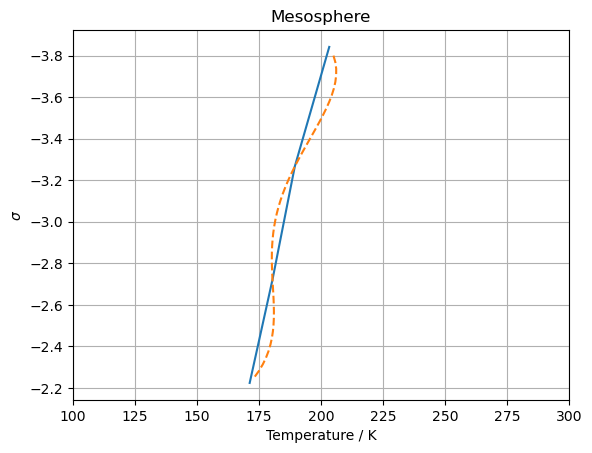

In [26]:
## Plotting the mesosphere

plt.plot(meso_temps, meso_log10_sigma_p, '-', poly_meso_temps, poly_meso_sigmas, '--')
plt.gca().invert_yaxis() # Pressure decreases with height
plt.xlabel('Temperature / K')
plt.ylabel(r'$\sigma$')
plt.title('Mesosphere')
plt.xlim(100,300)
plt.grid()
plt.show()

In [27]:
## This is for the troposphere

trop_z = np.polyfit(trop_log10_sigma_p, trop_temps, 1)
tropfunction = np.poly1d(trop_z)

poly_trop_sigmas = np.linspace(-1, 0, 50)
poly_trop_temps = tropfunction(poly_trop_sigmas)

tropfunction


poly1d([120.57183574, 285.47827322])

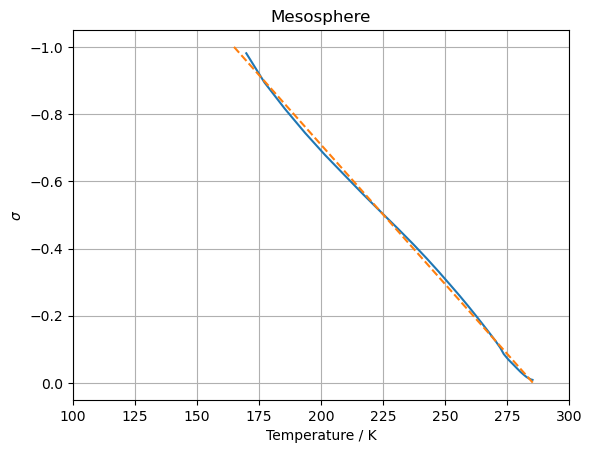

In [28]:
## Plotting the troposphere

plt.plot(trop_temps, trop_log10_sigma_p, '-', poly_trop_temps, poly_trop_sigmas, '--')
plt.gca().invert_yaxis() # Pressure decreases with height
plt.xlabel('Temperature / K')
plt.ylabel(r'$\sigma$')
plt.title('Mesosphere')
plt.xlim(100,300)
plt.grid()
plt.show()

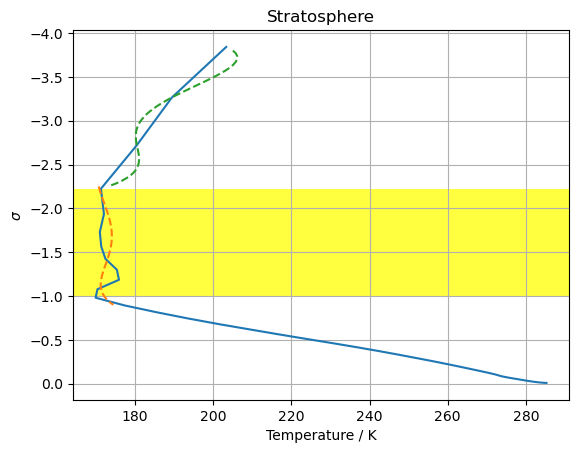

In [29]:
## Plotting the whole temperature profile with the stratospheric polynomial and a shaded area representing the stratosphere

plt.plot(H1temps, H1log10_sig_pressures, '-', poly_strat_temps, poly_strat_sigmas, '--', poly_meso_temps, poly_meso_sigmas, '--')
strat_high = np.log10(0.006)
strat_low = np.log10(0.1)
plt.axhspan(strat_low, strat_high, color='yellow', alpha=0.75, lw=0) # Shade the area representing the stratosphere
plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
plt.xlabel('Temperature / K')
plt.ylabel(r'$\sigma$')
plt.title('Stratosphere')
plt.grid()
plt.show()

In [30]:
# # Testing the accuracy of the stratosphere and mesosphere polynomial fits by inputting pressures that cover the full atmosphere range

# p = np.arange(-3.8, 0, 0.01)
# t = np.zeros(len(p))

# def temp_strat(sigma_p):
#     if sigma_p > -0.9: #Troposphere
#         return 120.7183574 * sigma_p + 285.47827322
#     elif sigma_p > -2.25: # Stratosphere
#         return 2.53197122e+01 * sigma_p**9 + 5.49418784e+02 * sigma_p**8 + 5.14741161e+03 * sigma_p**7 + 2.72999043e+04 * sigma_p**6 + 9.02416549e+04 * sigma_p**5 + 1.92643072e+05 * sigma_p**4 + 2.65380745e+05 * sigma_p**3 + 2.27337528e+05 * sigma_p**2 + 1.09834926e+05 * sigma_p + 2.29695343e+04
#     else: # Mesosphere
#         return 3.82949073e-03 * sigma_p**9 + 2.43852764e-03 * sigma_p**8 - 5.08313646e-02 * sigma_p**7 + 2.03902500e-01 * sigma_p**6 - 1.93617933e-01 * sigma_p**5 - 2.60371250e+00 * sigma_p**4 + 1.50749300e+01 * sigma_p**3 - 4.68621587e+00 * sigma_p**2 - 2.79833145e+02 * sigma_p - 2.43661521e+02

# for i in range(len(p)):
#     pressure = p[i]
#     t[i] = temp_strat(pressure)

In [31]:
# Testing the accuracy of the stratosphere and mesosphere polynomial fits by inputting pressures that cover the full atmosphere range

p = np.arange(-3.8, 0, 0.01)
t = np.zeros(len(p))

def temp_strat(sigma_p):
    if sigma_p > -0.9: #Troposphere
        # return tropfunction(sigma_p)
        return 120.5718357 * sigma_p + 285.47827322
    elif sigma_p > -2.25: # Stratosphere
        # return stratfunction(sigma_p)
        return 2.53197122e+01 * sigma_p**9 + 5.49418784e+02 * sigma_p**8 + 5.14741161e+03 * sigma_p**7 + 2.72999043e+04 * sigma_p**6 + 9.02416549e+04 * sigma_p**5 + 1.92643072e+05 * sigma_p**4 + 2.65380745e+05 * sigma_p**3 + 2.27337528e+05 * sigma_p **2 + 1.09834926e+05 * sigma_p + 2.29695343e+04
    else: # Mesosphere
        # return mesofunction(sigma_p)
        return 3.82949073e-03 * sigma_p**9 +  2.43852764e-03 * sigma_p**8 - 5.08313646e-02 * sigma_p**7 +  2.03902500e-01 * sigma_p**6 - 1.93617933e-01 * sigma_p**5 - 2.60371250e+00 * sigma_p**4 + 1.50749300e+01 * sigma_p**3 - 4.68621587e+00 * sigma_p**2 - 2.79833145e+02 * sigma_p - 2.43661521e+02
    
for i in range(len(p)):
    pressure = p[i]
    t[i] = temp_strat(pressure)

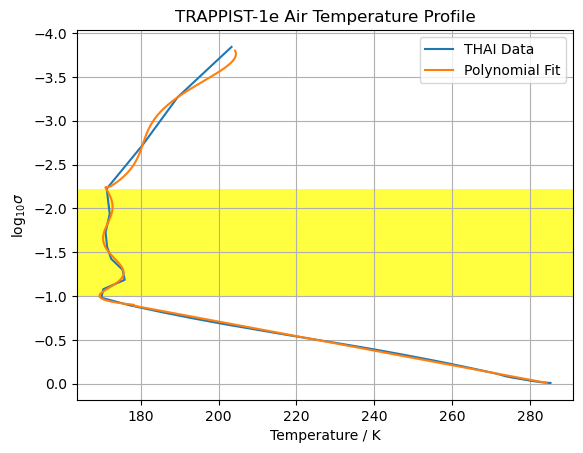

In [32]:
plt.plot(H1temps, H1log10_sig_pressures, label='THAI Data') # Original data
plt.plot(t, p, label='Polynomial Fit') # Plot produced by the double-polynomial function
strat_high = np.log10(0.006)
strat_low = np.log10(0.1)
plt.axhspan(strat_low, strat_high, color='yellow', alpha=0.75, lw=0) # Shade the area representing the stratosphere
plt.gca().invert_yaxis() # Get pressure going in the right direction on the axis
plt.xlabel('Temperature / K')
plt.ylabel(r'log$_{10}\sigma$')
plt.title('TRAPPIST-1e Air Temperature Profile')
plt.legend()
plt.grid()
plt.show()